CHAP 2 QUESTION 8

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the College.csv file
college = pd.read_csv("College.csv")

# Display the first 5 rows
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [2]:
#checking the shape 
college.shape

(777, 19)

In [3]:
college

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [4]:
# ------------------------------------------------------------
# (b) Set college names as index
# ------------------------------------------------------------

college3 = college.rename(
    {"Unnamed: 0": "College"},
    axis=1
)

college3 = college3.set_index("College")

college = college3

print("\nData after setting College as index:")
print(college.head())




Data after setting College as index:
                             Private  Apps  Accept  Enroll  Top10perc  \
College                                                                 
Abilene Christian University     Yes  1660    1232     721         23   
Adelphi University               Yes  2186    1924     512         16   
Adrian College                   Yes  1428    1097     336         22   
Agnes Scott College              Yes   417     349     137         60   
Alaska Pacific University        Yes   193     146      55         16   

                              Top25perc  F.Undergrad  P.Undergrad  Outstate  \
College                                                                       
Abilene Christian University         52         2885          537      7440   
Adelphi University                   29         2683         1227     12280   
Adrian College                       50         1036           99     11250   
Agnes Scott College                  89          510   

In [5]:
# ------------------------------------------------------------
# (c) Numerical summary
# ------------------------------------------------------------

print("\nNumerical Summary:")
print(college.describe().round(2))




Numerical Summary:
           Apps    Accept   Enroll  Top10perc  Top25perc  F.Undergrad  \
count    777.00    777.00   777.00     777.00      777.0       777.00   
mean    3001.64   2018.80   779.97      27.56       55.8      3699.91   
std     3870.20   2451.11   929.18      17.64       19.8      4850.42   
min       81.00     72.00    35.00       1.00        9.0       139.00   
25%      776.00    604.00   242.00      15.00       41.0       992.00   
50%     1558.00   1110.00   434.00      23.00       54.0      1707.00   
75%     3624.00   2424.00   902.00      35.00       69.0      4005.00   
max    48094.00  26330.00  6392.00      96.00      100.0     31643.00   

       P.Undergrad  Outstate  Room.Board    Books  Personal     PhD  Terminal  \
count       777.00    777.00      777.00   777.00    777.00  777.00    777.00   
mean        855.30  10440.67     4357.53   549.38   1340.64   72.66     79.70   
std        1522.43   4023.02     1096.70   165.11    677.07   16.33     14.72  

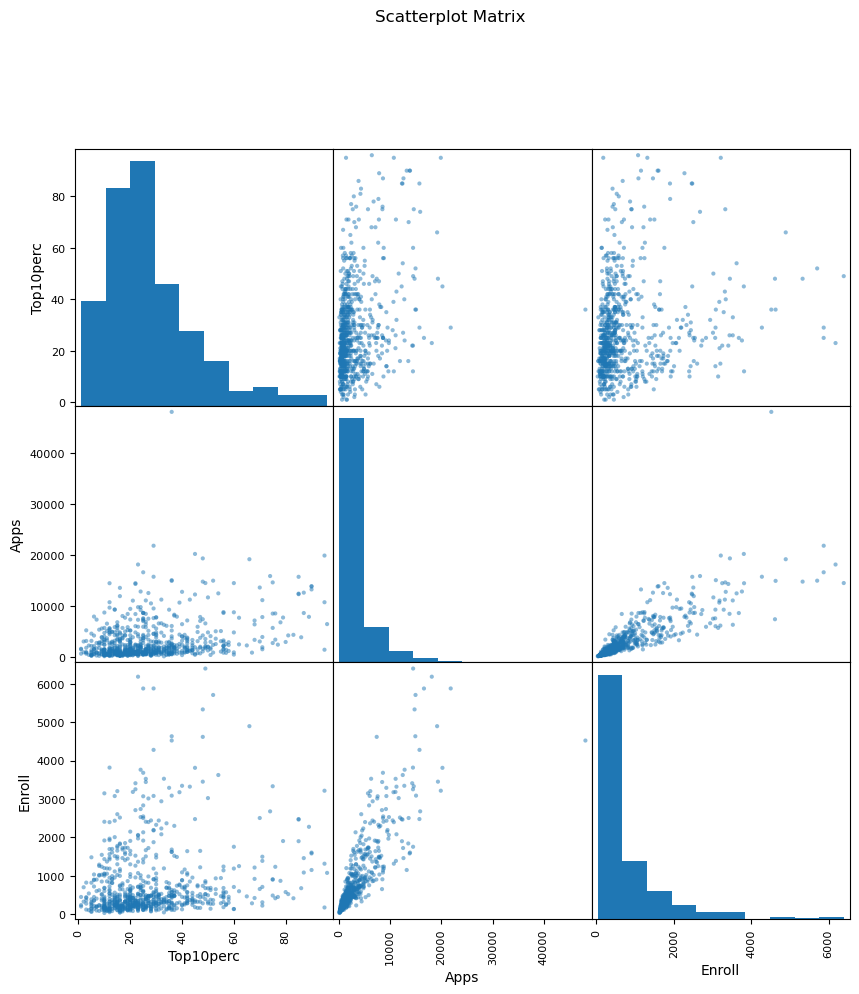

In [6]:
# ------------------------------------------------------------
# (d) Scatterplot matrix
# ------------------------------------------------------------

pd.plotting.scatter_matrix(
    college[["Top10perc", "Apps", "Enroll"]],
    figsize=(10, 10)
)

plt.suptitle(
    "Scatterplot Matrix",
    y=1.02
)

plt.show()

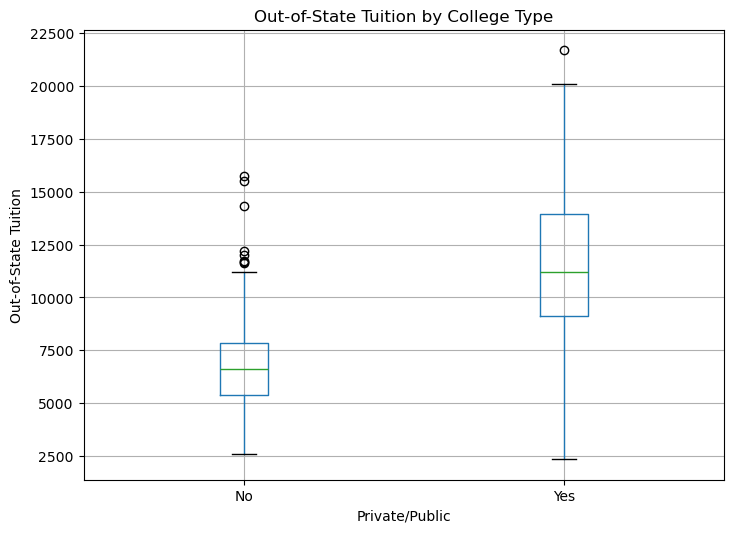

In [7]:

# ------------------------------------------------------------
# (e) Boxplot: Outstate versus Private
# ------------------------------------------------------------

college.boxplot(
    column="Outstate",
    by="Private",
    figsize=(8, 6)
)

plt.title("Out-of-State Tuition by College Type")
plt.suptitle("")
plt.xlabel("Private/Public")
plt.ylabel("Out-of-State Tuition")

plt.show()


Number of Elite and Non-Elite Universities:
Elite
No     699
Yes     78
Name: count, dtype: int64


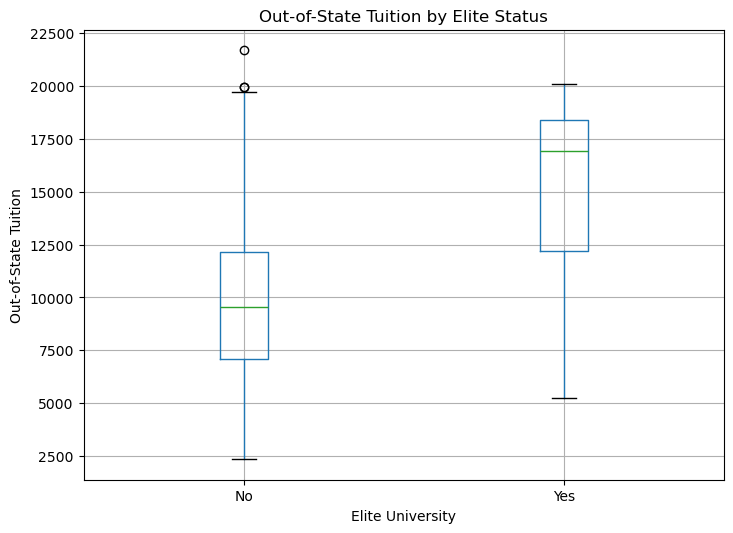

In [8]:
# ------------------------------------------------------------
# (f) Create Elite variable
# ------------------------------------------------------------

college["Elite"] = pd.cut(
    college["Top10perc"],
    bins=[0, 50, 100],
    labels=["No", "Yes"],
    include_lowest=True
)

print("\nNumber of Elite and Non-Elite Universities:")
print(college["Elite"].value_counts())


# Boxplot: Outstate versus Elite

college.boxplot(
    column="Outstate",
    by="Elite",
    figsize=(8, 6)
)

plt.title("Out-of-State Tuition by Elite Status")
plt.suptitle("")
plt.xlabel("Elite University")
plt.ylabel("Out-of-State Tuition")

plt.show()


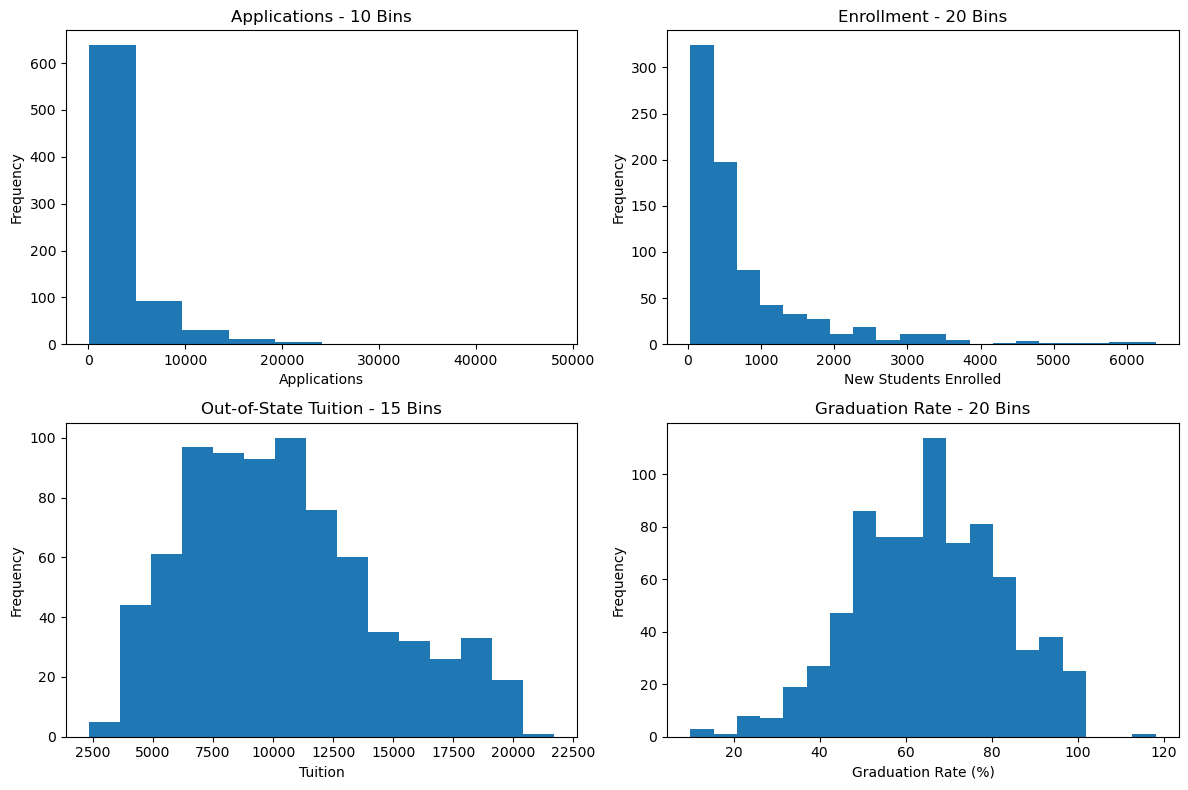

In [9]:
# ------------------------------------------------------------
# (g) Histograms
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

college["Apps"].plot.hist(
    bins=10,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Applications - 10 Bins")
axes[0, 0].set_xlabel("Applications")

college["Enroll"].plot.hist(
    bins=20,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Enrollment - 20 Bins")
axes[0, 1].set_xlabel("New Students Enrolled")

college["Outstate"].plot.hist(
    bins=15,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Out-of-State Tuition - 15 Bins")
axes[1, 0].set_xlabel("Tuition")

college["Grad.Rate"].plot.hist(
    bins=20,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Graduation Rate - 20 Bins")
axes[1, 1].set_xlabel("Graduation Rate (%)")

plt.tight_layout()
plt.show()

In [10]:
# ------------------------------------------------------------
# (h) Additional exploration
# ------------------------------------------------------------

print("\nNumber of Private and Public Colleges:")
print(college["Private"].value_counts())


print("\nAverage Out-of-State Tuition by College Type:")
print(college.groupby("Private")["Outstate"].mean().round(2))


print("\nAverage Graduation Rate by College Type:")
print(college.groupby("Private")["Grad.Rate"].mean().round(2))


print("\nCorrelation Matrix:")
print(
    college.select_dtypes(include=np.number)
    .corr()
    .round(2)
)


print("\nTop 10 Colleges by Applications:")
print(
    college.sort_values(
        "Apps",
        ascending=False
    )[["Apps", "Accept", "Enroll", "Private"]].head(10)
)


print("\nTop 10 Colleges by Graduation Rate:")
print(
    college.sort_values(
        "Grad.Rate",
        ascending=False
    )[["Grad.Rate", "Private", "Outstate"]].head(10)
)


Number of Private and Public Colleges:
Private
Yes    565
No     212
Name: count, dtype: int64

Average Out-of-State Tuition by College Type:
Private
No      6813.41
Yes    11801.69
Name: Outstate, dtype: float64

Average Graduation Rate by College Type:
Private
No     56.04
Yes    69.00
Name: Grad.Rate, dtype: float64

Correlation Matrix:
             Apps  Accept  Enroll  Top10perc  Top25perc  F.Undergrad  \
Apps         1.00    0.94    0.85       0.34       0.35         0.81   
Accept       0.94    1.00    0.91       0.19       0.25         0.87   
Enroll       0.85    0.91    1.00       0.18       0.23         0.96   
Top10perc    0.34    0.19    0.18       1.00       0.89         0.14   
Top25perc    0.35    0.25    0.23       0.89       1.00         0.20   
F.Undergrad  0.81    0.87    0.96       0.14       0.20         1.00   
P.Undergrad  0.40    0.44    0.51      -0.11      -0.05         0.57   
Outstate     0.05   -0.03   -0.16       0.56       0.49        -0.22   
Room.Boar